# CYBERNETIC PLANT - AI-DRIVEN HEALTH OPTIMIZATION
## STEP 1: DATA LOADING, TRAINING AND SAVING

In [ ]:
!pip install kaggle xgboost -q

In [1]:
import os
import zipfile
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive, files
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
)

In [2]:
drive.mount('/content/drive')
BASE = "/content/drive/MyDrive/plant_health_project"
os.makedirs(BASE, exist_ok=True)
print("Drive mounted. Folder ready:", BASE)

Mounted at /content/drive
Drive mounted. Folder ready: /content/drive/MyDrive/plant_health_project


```markdown
## 2. DOWNLOAD DATASET FROM KAGGLE

First, upload your `kaggle.json` file. You can generate one from your Kaggle account settings.
```

In [ ]:
os.makedirs("/root/.kaggle", exist_ok=True)
print("\n Upload your kaggle.json file:")
files.upload()
!mv kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json


 Upload your kaggle.json file:


Saving kaggle.json to kaggle.json


In [3]:
os.system(f"kaggle datasets download -d ziya07/plant-health-data -p {BASE}")

zip_path = f"{BASE}/plant-health-data.zip"
with zipfile.ZipFile(zip_path, 'r') as z:
    print("Files inside zip:", z.namelist())
    z.extractall(BASE)
print("Dataset downloaded and extracted.")

Files inside zip: ['plant_health_data.csv']
Dataset downloaded and extracted.


```markdown
## 3. LOAD DATA

Now, let's load the data from the extracted CSV file into a pandas DataFrame.
```

In [4]:
csv_files = [f for f in os.listdir(BASE) if f.endswith(".csv")]
if not csv_files:
    raise FileNotFoundError("No CSV found after extraction. Check zip contents above.")

data_csv = None
for f in csv_files:
    if "plant_health_data" in f.lower():
        data_csv = f
        break

if data_csv is None:
    raise FileNotFoundError("'plant_health_data.csv' not found after extraction.")

DATA_PATH = f"{BASE}/{data_csv}"
print(f"Loading: {DATA_PATH}")
df = pd.read_csv(DATA_PATH)

print(f"Dataset Shape : {df.shape}")
print(f"Columns       : {df.columns.tolist()}")
display(df.head())

Loading: /content/drive/MyDrive/plant_health_project/plant_health_data.csv
Dataset Shape : (1200, 14)
Columns       : ['Timestamp', 'Plant_ID', 'Soil_Moisture', 'Ambient_Temperature', 'Soil_Temperature', 'Humidity', 'Light_Intensity', 'Soil_pH', 'Nitrogen_Level', 'Phosphorus_Level', 'Potassium_Level', 'Chlorophyll_Content', 'Electrochemical_Signal', 'Plant_Health_Status']


,Timestamp,Plant_ID,Soil_Moisture,Ambient_Temperature,Soil_Temperature,Humidity,Light_Intensity,Soil_pH,Nitrogen_Level,Phosphorus_Level,Potassium_Level,Chlorophyll_Content,Electrochemical_Signal,Plant_Health_Status
0,2024-10-03 10:54:53.407995,1,27.521109,22.240245,21.900435,55.291904,556.172805,5.581955,10.003650,45.806852,39.076199,35.703006,0.941402,High Stress
1,2024-10-03 16:54:53.407995,1,14.835566,21.706763,18.680892,63.949181,596.136721,7.135705,30.712562,25.394393,17.944826,27.993296,0.164899,High Stress
2,2024-10-03 22:54:53.407995,1,17.086362,21.180946,15.392939,67.837956,591.124627,5.656852,29.337002,27.573892,35.706530,43.646308,1.081728,High Stress
3,2024-10-04 04:54:53.407995,1,15.336156,22.593302,22.778394,58.190811,241.412476,5.584523,16.966621,26.180705,26.257746,37.838095,1.186088,High Stress
4,2024-10-04 10:54:53.407995,1,39.822216,28.929001,18.100937,63.772036,444.493830,5.919707,10.944961,37.898907,37.654483,48.265812,1.609805,High Stress


```markdown
## 4. FEATURE ENGINEERING

Here, we will create new features from existing ones and handle the target encoding.
```

In [5]:
if 'Timestamp' in df.columns:
    df['Timestamp'] = pd.to_datetime(df['Timestamp'])
    df = df.sort_values("Timestamp").reset_index(drop=True)

    df['hour']        = df['Timestamp'].dt.hour
    df['day']         = df['Timestamp'].dt.day
    df['month']       = df['Timestamp'].dt.month
    df['day_of_week'] = df['Timestamp'].dt.dayofweek
else:
    print("Timestamp column not found or already dropped - skipping time features")

if 'Ambient_Temperature' in df.columns and 'Soil_Temperature' in df.columns:
    df['temp_diff'] = df['Ambient_Temperature'] - df['Soil_Temperature']
else:
    print("Missing 'Ambient_Temperature' or 'Soil_Temperature' for 'temp_diff'")

if 'Soil_Moisture' in df.columns and 'Soil_pH' in df.columns:
    df['moisture_x_ph'] = df['Soil_Moisture'] * df['Soil_pH']
else:
    print("Missing 'Soil_Moisture' or 'Soil_pH' for 'moisture_x_ph'")

if 'Nitrogen_Level' in df.columns and 'Phosphorus_Level' in df.columns and 'Potassium_Level' in df.columns:
    df['npk_total'] = df['Nitrogen_Level'] + df['Phosphorus_Level'] + df['Potassium_Level']
else:
    print("Missing NPK levels for 'npk_total'")

if 'Ambient_Temperature' in df.columns and 'Soil_Moisture' in df.columns:
    df['stress_index'] = df['Ambient_Temperature'] / (df['Soil_Moisture'] + 1)
else:
    print("Missing 'Ambient_Temperature' or 'Soil_Moisture' for 'stress_index'")

if 'Light_Intensity' in df.columns and 'Humidity' in df.columns:
    df['light_per_humid'] = df['Light_Intensity'] / (df['Humidity'] + 1)
else:
    print("Missing 'Light_Intensity' or 'Humidity' for 'light_per_humid'")

if 'Chlorophyll_Content' in df.columns and 'Light_Intensity' in df.columns:
    df['chloro_x_light'] = df['Chlorophyll_Content'] * df['Light_Intensity']
else:
    print("Missing 'Chlorophyll_Content' or 'Light_Intensity' for 'chloro_x_light'")

if 'Soil_pH' in df.columns and 'Soil_Moisture' in df.columns:
    df['ph_x_moisture'] = df['Soil_pH'] * df['Soil_Moisture']
else:
    print("Missing 'Soil_pH' or 'Soil_Moisture' for 'ph_x_moisture'")

df = df.drop([col for col in ["Timestamp", "Plant_ID"] if col in df.columns], axis=1, errors='ignore')

if 'Plant_Health_Status' in df.columns and df['Plant_Health_Status'].dtype == object:
    encoder = LabelEncoder()
    df['Plant_Health_Status'] = encoder.fit_transform(df['Plant_Health_Status'])
elif 'Plant_Health_Status' in df.columns:
    print("Target already encoded - skipping")
else:
    print("'Plant_Health_Status' column not found for encoding.")

In [ ]:
print(df.columns.tolist())

['Timestamp', 'Plant_ID', 'Soil_Moisture', 'Ambient_Temperature', 'Soil_Temperature', 'Humidity', 'Light_Intensity', 'Soil_pH', 'Nitrogen_Level', 'Phosphorus_Level', 'Potassium_Level', 'Chlorophyll_Content', 'Electrochemical_Signal', 'Plant_Health_Status']


```markdown
## 5. TRAIN / TEST SPLIT (time-aware)

We'll split the data into training and testing sets, ensuring a time-aware split.
```

In [6]:
if 'Plant_Health_Status' not in df.columns:
    print("Error: 'Plant_Health_Status' column not found in DataFrame for split.")
    print("Current columns in df:", df.columns.tolist())
    raise KeyError("'Plant_Health_Status' column missing.")

split   = int(len(df) * 0.8)
X_train = df.iloc[:split].drop("Plant_Health_Status", axis=1)
y_train = df.iloc[:split]["Plant_Health_Status"]
X_test  = df.iloc[split:].drop("Plant_Health_Status", axis=1)
y_test  = df.iloc[split:]["Plant_Health_Status"]

print(f"Train samples : {len(X_train)}")
print(f"Test  samples : {len(X_test)}")
print(f"Features      : {X_train.columns.tolist()}")

Train samples : 960
Test  samples : 240
Features      : ['Soil_Moisture', 'Ambient_Temperature', 'Soil_Temperature', 'Humidity', 'Light_Intensity', 'Soil_pH', 'Nitrogen_Level', 'Phosphorus_Level', 'Potassium_Level', 'Chlorophyll_Content', 'Electrochemical_Signal', 'hour', 'day', 'month', 'day_of_week', 'temp_diff', 'moisture_x_ph', 'npk_total', 'stress_index', 'light_per_humid', 'chloro_x_light', 'ph_x_moisture']


```markdown
## 6. TRAIN XGBoost MODEL

Now, let's train an XGBoost Classifier model.
```

In [7]:
print("Training XGBoost model...")

model = XGBClassifier(
    n_estimators          = 1000,
    max_depth             = 6,
    learning_rate         = 0.01,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    min_child_weight      = 1,
    gamma                 = 0,
    reg_alpha             = 0.1,
    reg_lambda            = 1,
    objective             = 'multi:softprob',
    num_class             = len(encoder.classes_) if 'encoder' in locals() else 3,
    eval_metric           = 'mlogloss',
    early_stopping_rounds = 50,
    random_state          = 42,
    n_jobs                = -1,
    verbosity             = 0,
)

model.fit(
    X_train, y_train,
    eval_set = [(X_test, y_test)],
    verbose  = 200,
)

Training XGBoost model...
[0]	validation_0-mlogloss:1.06817
[200]	validation_0-mlogloss:0.15621
[400]	validation_0-mlogloss:0.03845
[600]	validation_0-mlogloss:0.01660
[800]	validation_0-mlogloss:0.01169
[969]	validation_0-mlogloss:0.01138


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=50,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=0,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=1, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=1000, n_jobs=-1, num_class=3, ...)

```markdown
## 7. EVALUATE MODEL

Let's evaluate the trained model's performance using accuracy, classification report, confusion matrix, and feature importance.
```

In [8]:
preds = model.predict(X_test)
acc   = accuracy_score(y_test, preds)

print(f"Final accuracy on real test data : {acc*100:.2f}%")
if 'encoder' in locals():
    print(classification_report(y_test, preds, target_names=encoder.classes_))
else:
    print(classification_report(y_test, preds))

Final accuracy on real test data : 99.58%
                 precision    recall  f1-score   support

        Healthy       1.00      0.98      0.99        60
    High Stress       1.00      1.00      1.00        96
Moderate Stress       0.99      1.00      0.99        84

       accuracy                           1.00       240
      macro avg       1.00      0.99      1.00       240
   weighted avg       1.00      1.00      1.00       240



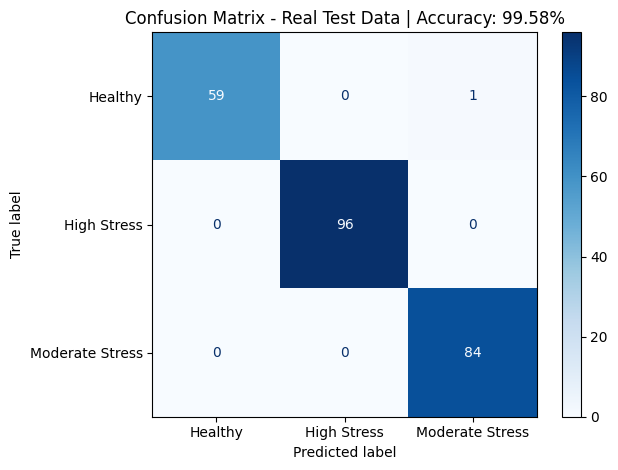

In [9]:
if 'encoder' in locals():
    ConfusionMatrixDisplay.from_predictions(
        y_test, preds,
        display_labels = encoder.classes_,
        cmap           = 'Blues',
    )
else:
    ConfusionMatrixDisplay.from_predictions(
        y_test, preds,
        cmap           = 'Blues',
    )
plt.title(f"Confusion Matrix - Real Test Data | Accuracy: {acc*100:.2f}%")
plt.tight_layout()
plt.show()

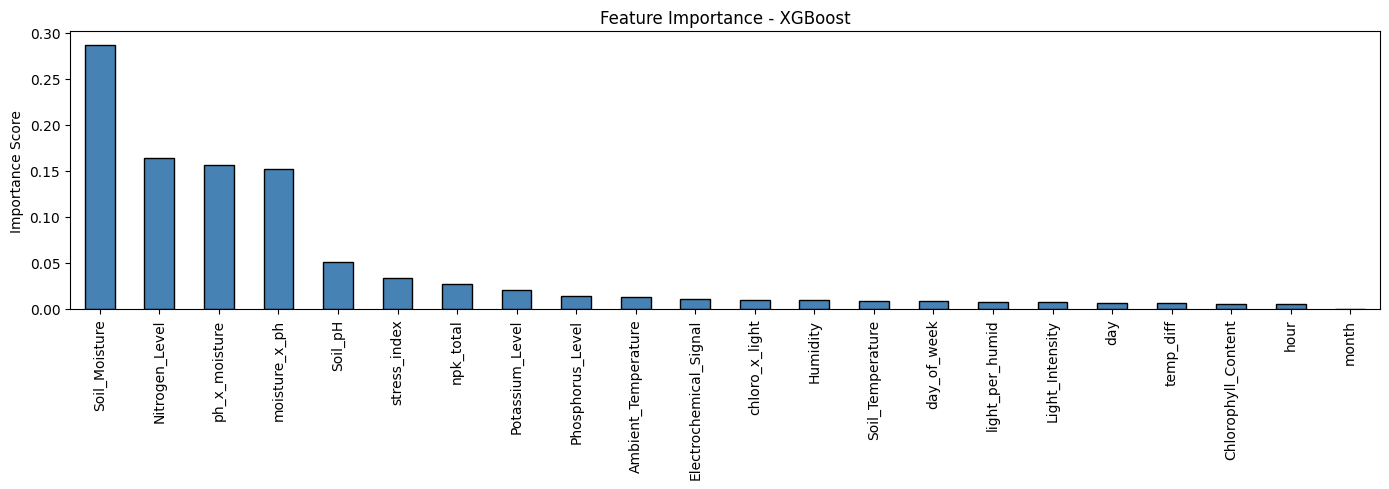

In [10]:
feat_imp = pd.Series(model.feature_importances_, index=X_train.columns)
feat_imp.sort_values(ascending=False).plot(
    kind      = 'bar',
    figsize   = (14, 5),
    color     = 'steelblue',
    edgecolor = 'black',
)
plt.title("Feature Importance - XGBoost")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()

```markdown
## 8. SAVE MODEL + ENCODER + FEATURE COLUMNS

Finally, we will save the trained model, the LabelEncoder, and the list of feature columns for future use.
```

In [11]:
joblib.dump(model,   f"{BASE}/plant_health_model.pkl")
if 'encoder' in locals():
    joblib.dump(encoder, f"{BASE}/plant_health_encoder.pkl")
pd.Series(X_train.columns.tolist()).to_csv(
    f"{BASE}/feature_columns.csv", index=False
)

print("Model saved     ->", f"{BASE}/plant_health_model.pkl")
if 'encoder' in locals():
    print("Encoder saved   ->", f"{BASE}/plant_health_encoder.pkl")
print("Features saved  ->", f"{BASE}/feature_columns.csv")

Model saved     -> /content/drive/MyDrive/plant_health_project/plant_health_model.pkl
Encoder saved   -> /content/drive/MyDrive/plant_health_project/plant_health_encoder.pkl
Features saved  -> /content/drive/MyDrive/plant_health_project/feature_columns.csv


STEP 1 COMPLETE - Now run Step 2 for dummy data testing.

Model loaded.
Classes  : ['Healthy', 'High Stress', 'Moderate Stress']
Features : 22

Test file  : https://raw.githubusercontent.com/eNVy047/bt3086-major-project/main/test_data.csv
Shape      : (600, 14)

Class Distribution:
Plant_Health_Status
Healthy            223
Moderate Stress    211
High Stress        166
Name: count, dtype: int64



,Timestamp,Plant_ID,Soil_Moisture,Ambient_Temperature,Soil_Temperature,Humidity,Light_Intensity,Soil_pH,Nitrogen_Level,Phosphorus_Level,Potassium_Level,Chlorophyll_Content,Electrochemical_Signal,Plant_Health_Status
0,2025-03-01 00:00:00,PLT3732,21.187173,17.685219,18.351310,55.646891,405.503491,6.022314,19.759482,34.216874,27.890871,15.000000,0.200000,Moderate Stress
1,2025-03-01 06:00:00,PLT4264,36.410290,33.184771,21.803634,40.189088,734.321218,6.800573,44.131692,38.296997,30.508067,23.398574,0.866984,Healthy
2,2025-03-01 12:00:00,PLT5859,19.256298,22.233754,21.791616,66.636892,612.838037,7.268399,16.128211,26.411072,24.909859,33.623270,1.204874,Moderate Stress
3,2025-03-01 18:00:00,PLT8891,24.050751,24.104876,22.377983,80.214464,787.328647,5.846692,27.263828,27.447577,7.746150,33.670809,1.323068,Moderate Stress
4,2025-03-02 00:00:00,PLT5373,26.366051,25.687476,19.689549,41.154552,349.213945,6.639046,5.000000,41.023163,28.980445,63.914207,2.349848,High Stress


Preprocessing done. Predicting on 600 samples ...
Test accuracy : 92.50%
Classification Report:

                 precision    recall  f1-score   support

        Healthy       0.94      0.96      0.95       223
    High Stress       0.92      0.95      0.94       166
Moderate Stress       0.91      0.87      0.89       211

       accuracy                           0.93       600
      macro avg       0.92      0.93      0.93       600
   weighted avg       0.92      0.93      0.92       600



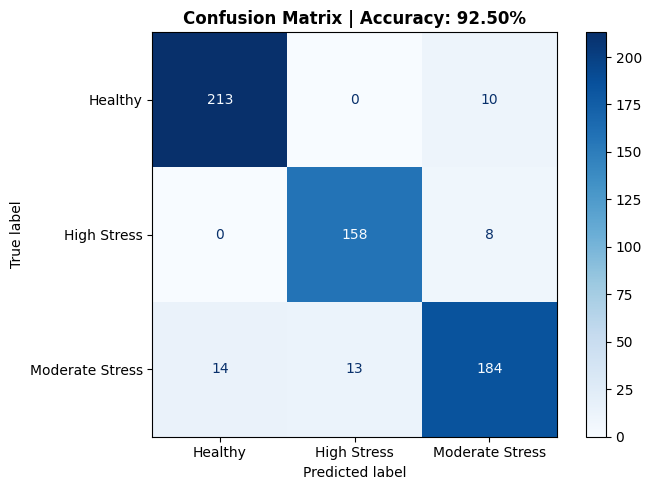

Sample Predictions (first 15 rows):


,Soil_Moisture,Ambient_Temperature,Humidity,Soil_pH,npk_total,Actual,Predicted,Correct
0,21.187173,17.685219,55.646891,6.022314,81.867227,Moderate Stress,Moderate Stress,True
1,36.410290,33.184771,40.189088,6.800573,112.936756,Healthy,Healthy,True
2,19.256298,22.233754,66.636892,7.268399,67.449142,Moderate Stress,High Stress,False
3,24.050751,24.104876,80.214464,5.846692,62.457555,Moderate Stress,Moderate Stress,True
4,26.366051,25.687476,41.154552,6.639046,75.003608,High Stress,High Stress,True
5,34.431377,19.674723,54.868001,7.214106,81.132579,Healthy,Healthy,True
6,23.875647,17.310889,65.947624,5.043491,68.742651,Moderate Stress,Moderate Stress,True
7,22.585406,26.219914,58.862329,5.494083,71.294911,Moderate Stress,Moderate Stress,True
8,42.859772,24.984617,51.590276,6.980468,89.447846,Healthy,Healthy,True
9,19.991019,21.165518,38.116784,6.046280,113.572712,High Stress,High Stress,True


Total Samples : 600
Correct       : 555  (92.50%)
Wrong         : 45  (7.50%)


In [21]:
import os
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from google.colab import drive
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

BASE     = "/content/drive/MyDrive/plant_health_project"

model    = joblib.load(f"{BASE}/plant_health_model.pkl")
encoder  = joblib.load(f"{BASE}/plant_health_encoder.pkl")
features = pd.read_csv(f"{BASE}/feature_columns.csv").iloc[:, 0].tolist()

print("Model loaded.")
print(f"Classes  : {list(encoder.classes_)}")
print(f"Features : {len(features)}\n")

TEST_PATH = "https://raw.githubusercontent.com/eNVy047/bt3086-major-project/main/test_data.csv"

df = pd.read_csv(TEST_PATH)

print(f"Test file  : {TEST_PATH}")
print(f"Shape      : {df.shape}")
print(f"\nClass Distribution:")
print(df['Plant_Health_Status'].value_counts())
print()
display(df.head(5))

df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df = df.sort_values("Timestamp").reset_index(drop=True)

df['hour']        = df['Timestamp'].dt.hour
df['day']         = df['Timestamp'].dt.day
df['month']       = df['Timestamp'].dt.month
df['day_of_week'] = df['Timestamp'].dt.dayofweek

df['temp_diff']       = df['Ambient_Temperature'] - df['Soil_Temperature']
df['moisture_x_ph']   = df['Soil_Moisture'] * df['Soil_pH']
df['npk_total']       = df['Nitrogen_Level'] + df['Phosphorus_Level'] + df['Potassium_Level']
df['stress_index']    = df['Ambient_Temperature'] / (df['Soil_Moisture'] + 1)
df['light_per_humid'] = df['Light_Intensity'] / (df['Humidity'] + 1)
df['chloro_x_light']  = df['Chlorophyll_Content'] * df['Light_Intensity']
df['ph_x_moisture']   = df['Soil_pH'] * df['Soil_Moisture']

df['Plant_Health_Status'] = encoder.transform(df['Plant_Health_Status'])

X_test = df[features]
y_test = df['Plant_Health_Status']

print(f"Preprocessing done. Predicting on {len(X_test)} samples ...")

preds = model.predict(X_test)
acc   = accuracy_score(y_test, preds)

print(f"Test accuracy : {acc*100:.2f}%")

print("Classification Report:\n")
print(classification_report(y_test, preds, target_names=encoder.classes_))

fig, axes = plt.subplots(1, 1, figsize=(7, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, preds,
    display_labels = encoder.classes_,
    cmap           = 'Blues',
    ax             = axes,
)
axes.set_title(
    f"Confusion Matrix | Accuracy: {acc*100:.2f}%",
    fontsize=12, fontweight='bold'
)

plt.tight_layout()
plt.show()

results = df[['Soil_Moisture', 'Ambient_Temperature',
              'Humidity', 'Soil_pH', 'npk_total']].copy()
results['Actual']    = encoder.inverse_transform(y_test)
results['Predicted'] = encoder.inverse_transform(preds)
results['Correct']   = results['Actual'] == results['Predicted']

print("Sample Predictions (first 15 rows):")
display(results.head(15))

correct = results['Correct'].sum()
wrong   = len(results) - correct
print(f"Total Samples : {len(results)}")
print(f"Correct       : {correct}  ({correct/len(results)*100:.2f}%)")
print(f"Wrong         : {wrong}  ({wrong/len(results)*100:.2f}%)")

## m odel ui by streamlit and ngrok

In [13]:
!pip install streamlit pyngrok -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 78.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 118.2 MB/s eta 0:00:00


In [18]:
%%writefile app.py

import streamlit as st
import pandas as pd
import joblib
import numpy as np
import datetime
import os

BASE = "/content/drive/MyDrive/plant_health_project"

@st.cache_resource
def load_model_artifacts():
    try:
        model    = joblib.load(f"{BASE}/plant_health_model.pkl")
        encoder  = joblib.load(f"{BASE}/plant_health_encoder.pkl")
        features = pd.read_csv(f"{BASE}/feature_columns.csv").iloc[:, 0].tolist()
        return model, encoder, features
    except FileNotFoundError as e:
        st.error(f"Error loading model artifacts: {e}. Make sure you have run the training and saving steps.")
        st.stop()

model, encoder, features = load_model_artifacts()

def apply_feature_engineering(input_df_row):
    processed_df = input_df_row.copy()

    if 'Timestamp' in processed_df.columns:
        processed_df['Timestamp'] = pd.to_datetime(processed_df['Timestamp'])
        processed_df['hour']        = processed_df['Timestamp'].dt.hour
        processed_df['day']         = processed_df['Timestamp'].dt.day
        processed_df['month']       = processed_df['Timestamp'].dt.month
        processed_df['day_of_week'] = processed_df['Timestamp'].dt.dayofweek
    else:
        pass

    if 'Ambient_Temperature' in processed_df.columns and 'Soil_Temperature' in processed_df.columns:
        processed_df['temp_diff'] = processed_df['Ambient_Temperature'] - processed_df['Soil_Temperature']

    if 'Soil_Moisture' in processed_df.columns and 'Soil_pH' in processed_df.columns:
        processed_df['moisture_x_ph'] = processed_df['Soil_Moisture'] * processed_df['Soil_pH']

    if 'Nitrogen_Level' in processed_df.columns and 'Phosphorus_Level' in processed_df.columns and 'Potassium_Level' in processed_df.columns:
        processed_df['npk_total'] = processed_df['Nitrogen_Level'] + processed_df['Phosphorus_Level'] + processed_df['Potassium_Level']

    if 'Ambient_Temperature' in processed_df.columns and 'Soil_Moisture' in processed_df.columns:
        processed_df['stress_index'] = processed_df['Ambient_Temperature'] / (processed_df['Soil_Moisture'] + 1)

    if 'Light_Intensity' in processed_df.columns and 'Humidity' in processed_df.columns:
        processed_df['light_per_humid'] = processed_df['Light_Intensity'] / (processed_df['Humidity'] + 1)

    if 'Chlorophyll_Content' in processed_df.columns and 'Light_Intensity' in processed_df.columns:
        processed_df['chloro_x_light'] = processed_df['Chlorophyll_Content'] * processed_df['Light_Intensity']

    if 'Soil_pH' in processed_df.columns and 'Soil_Moisture' in processed_df.columns:
        processed_df['ph_x_moisture'] = processed_df['Soil_pH'] * processed_df['Soil_Moisture']

    processed_df = processed_df.drop(columns=[col for col in ["Timestamp", "Plant_ID"] if col in processed_df.columns], errors='ignore')

    for feature in features:
        if feature not in processed_df.columns:
            processed_df[feature] = 0.0

    return processed_df[features]

st.set_page_config(page_title="Plant Health Predictor", layout="centered")
st.title("🌿 AI-Driven Plant Health Optimization")
st.markdown("Enter sensor readings to predict the plant's health status.")

with st.form("prediction_form"):
    st.subheader("Sensor Readings")

    col1, col2 = st.columns(2)
    with col1:
        timestamp_date = st.date_input("Date", datetime.date.today())
        timestamp_time = st.time_input("Time", datetime.datetime.now().time())
        soil_moisture = st.number_input("Soil Moisture", min_value=0.0, value=25.0, format="%.2f")
        ambient_temperature = st.number_input("Ambient Temperature (°C)", min_value=-50.0, max_value=50.0, value=25.0, format="%.2f")
        soil_temperature = st.number_input("Soil Temperature (°C)", min_value=-50.0, max_value=50.0, value=20.0, format="%.2f")
        humidity = st.number_input("Humidity (%)", min_value=0.0, max_value=100.0, value=60.0, format="%.2f")
    with col2:
        light_intensity = st.number_input("Light Intensity (lux)", min_value=0.0, value=500.0, format="%.2f")
        soil_ph = st.number_input("Soil pH", min_value=0.0, max_value=14.0, value=6.5, format="%.2f")
        nitrogen_level = st.number_input("Nitrogen Level (ppm)", min_value=0.0, value=30.0, format="%.2f")
        phosphorus_level = st.number_input("Phosphorus Level (ppm)", min_value=0.0, value=15.0, format="%.2f")
        potassium_level = st.number_input("Potassium Level (ppm)", min_value=0.0, value=20.0, format="%.2f")
        chlorophyll_content = st.number_input("Chlorophyll Content", min_value=0.0, value=40.0, format="%.2f")
        electrochemical_signal = st.number_input("Electrochemical Signal", min_value=0.0, value=1.0, format="%.2f")

    submitted = st.form_submit_button("Predict Plant Health")

    if submitted:
        with st.spinner('Predicting plant health...'):
            raw_data = {
                'Timestamp': pd.to_datetime(f"{timestamp_date} {timestamp_time}"),
                'Soil_Moisture': soil_moisture,
                'Ambient_Temperature': ambient_temperature,
                'Soil_Temperature': soil_temperature,
                'Humidity': humidity,
                'Light_Intensity': light_intensity,
                'Soil_pH': soil_ph,
                'Nitrogen_Level': nitrogen_level,
                'Phosphorus_Level': phosphorus_level,
                'Potassium_Level': potassium_level,
                'Chlorophyll_Content': chlorophyll_content,
                'Electrochemical_Signal': electrochemical_signal,
                'Plant_ID': 'UI_TEST'
            }

            input_df_row = pd.DataFrame([raw_data])

            processed_features = apply_feature_engineering(input_df_row)

            if processed_features is not None and not processed_features.empty:
                prediction_encoded = model.predict(processed_features)
                prediction_proba   = model.predict_proba(processed_features)
                predicted_status   = encoder.inverse_transform(prediction_encoded)

                st.subheader("Prediction Results")
                st.success(f"The predicted Plant Health Status is: **{predicted_status[0]}**")

                st.write("**Confidence:**")
                proba_df = pd.DataFrame({
                    'Status': encoder.classes_,
                    'Probability': prediction_proba[0]
                }).sort_values(by='Probability', ascending=False)
                st.dataframe(proba_df, hide_index=True)

                st.markdown("--- This prediction is based on the provided sensor readings. --- ")
            else:
                st.error("Could not process features for prediction. Please check your inputs.")

Overwriting app.py


In [19]:
import subprocess
import time
from pyngrok import ngrok, conf
from google.colab import userdata

try:
    NGROK_AUTH_TOKEN = userdata.get('NGROK_AUTH_TOKEN')
except KeyError:
    NGROK_AUTH_TOKEN = None

if NGROK_AUTH_TOKEN:
    conf.get_default().auth_token = NGROK_AUTH_TOKEN
    print("Ngrok authtoken configured.")
else:
    print("Ngrok authtoken not found in Colab secrets. Ngrok tunnels might be rate-limited or require manual authentication.")
    print("To add: Go to '🔑' icon in left panel -> 'Add a new secret' -> Name: NGROK_AUTH_TOKEN, Value: <your_auth_token>")

print("Starting Streamlit app...")
streamlit_proc = subprocess.Popen(["streamlit", "run", "app.py", "--server.port", "8501", "--server.enableCORS", "false", "--server.enableXsrfProtection", "false"])


time.sleep(5)

try:
    ngrok.kill()
    public_url = ngrok.connect(8501)
    print(f"Streamlit app is available at: {public_url}")
    print("Press Ctrl+C in this cell to stop Streamlit and ngrok.")


    while True:
        time.sleep(1)
except KeyboardInterrupt:
    print("Stopping ngrok and Streamlit...")
    ngrok.kill()
    streamlit_proc.terminate()
    streamlit_proc.wait()
    print("Stopped.")
except Exception as e:
    print(f"An error occurred with ngrok: {e}")
    if streamlit_proc.poll() is None:
        streamlit_proc.terminate()
        streamlit_proc.wait()

Ngrok authtoken configured.
Starting Streamlit app...
Streamlit app is available at: NgrokTunnel: "https://94d6-34-87-93-38.ngrok-free.app" -> "http://localhost:8501"
Press Ctrl+C in this cell to stop Streamlit and ngrok.
Stopping ngrok and Streamlit...
Stopped.
